In [1]:
# IPython extension to reload modules before executing user code.
# useful to see immediate results in notebook when modifying imported scripts
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys
import os


# Add the ../py directory to sys.path
# This allows importing modules from the py directory as if they were in the current directory
module_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'py'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Verify it works
print(f"Added to path: {module_path}")

Added to path: /Users/eyal/projects/elzurdo/dpitg/py


In [35]:
from utils import print_env_info

from utils_viz import (
    FIG_WIDTH,
    FIG_HEIGHT,
    SMALL_SIZE,
    MEDIUM_SIZE,
    BIGGER_SIZE,
    plot_decision_rates_nhst,
)


from utils_experiments_binomial import (
    BinaryPvalueAccounting,
    BinomialSimulation,
    stop_decision_multiple_experiments_nhst,
    # BinomialHypothesis, 
    # run_simulations_and_analysis_report,
    # CI_FRACTION,
    )

from utils_experiments_shared import (
    SEED,
    #report_success_rates_multiple_algos
)

In [5]:
print_env_info()

Last run: 2026-07-30 10:19:02.430072
Python: 3.10.13
Platform: macOS-13.0-x86_64-i386-64bit
pandas: 2.3.3
numpy: 2.2.6
scipy: 1.15.3
matplotlib: 3.10.9
notebook: 7.6.0


In [8]:
plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("axes", titlesize=BIGGER_SIZE)  # fontsize of the figure title

plt.rcParams["figure.figsize"] = FIG_WIDTH, FIG_HEIGHT
# plt.rcParams["hatch.linewidth"] = 0.2

plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

In [27]:
# used for storing an linking to binary calucations already performed
binary_pvalue_accounting = BinaryPvalueAccounting()
binary_pvalue_accounting.successes_n_to_pvalue(7,10) 

np.float64(0.34375)

# Simulations

In [17]:
θ_true = 0.5

In [19]:
N_EXPERIMENTS = 50 # 2000
N_SAMPLES = 100 #30000 #1500  # in paper called M

In [22]:
%%time

# was called synth_0pt5
sequences_0pt5 = BinomialSimulation(
    success_rate=θ_true,
    n_samples = N_SAMPLES,
    n_experiments = N_EXPERIMENTS,
    seed=SEED)

Generating synthetic data with parameter values:
0.5: true success rate
50: experiments
100: sample size per experiment
CPU times: user 608 μs, sys: 455 μs, total: 1.06 ms
Wall time: 864 μs


# Hypothesis

In [25]:
θ_null = 0.5

# p-value False Positive Rate threshold
αfpr = 0.05

In [31]:
hypo_0pt5_results = stop_decision_multiple_experiments_nhst(
experiments= sequences_0pt5.experiments,
p_value_thresh= αfpr,
success_rate_null= θ_null,
alternative= 'two-sided',
binary_pvalue_accounting= binary_pvalue_accounting,
) 

hypo_0pt5_results.keys()

dict_keys(['iteration_stopping_on_or_prior', 'experiment_stop_results'])

# Results

In [33]:
df_experiment_stats = pd.DataFrame(hypo_0pt5_results['experiment_stop_results'])
df_experiment_stats.index.name = 'experiment_number'
df_experiment_stats['sample_success_rate'] = df_experiment_stats['successes'] * 1. / df_experiment_stats['trials']


print(df_experiment_stats.shape)
df_experiment_stats.head(4)

(50, 4)


,successes,trials,p_value,sample_success_rate
experiment_number,,,,
0,47,100,0.617299,0.470000
1,51,100,0.920411,0.510000
2,49,79,0.042165,0.620253
3,51,100,0.920411,0.510000


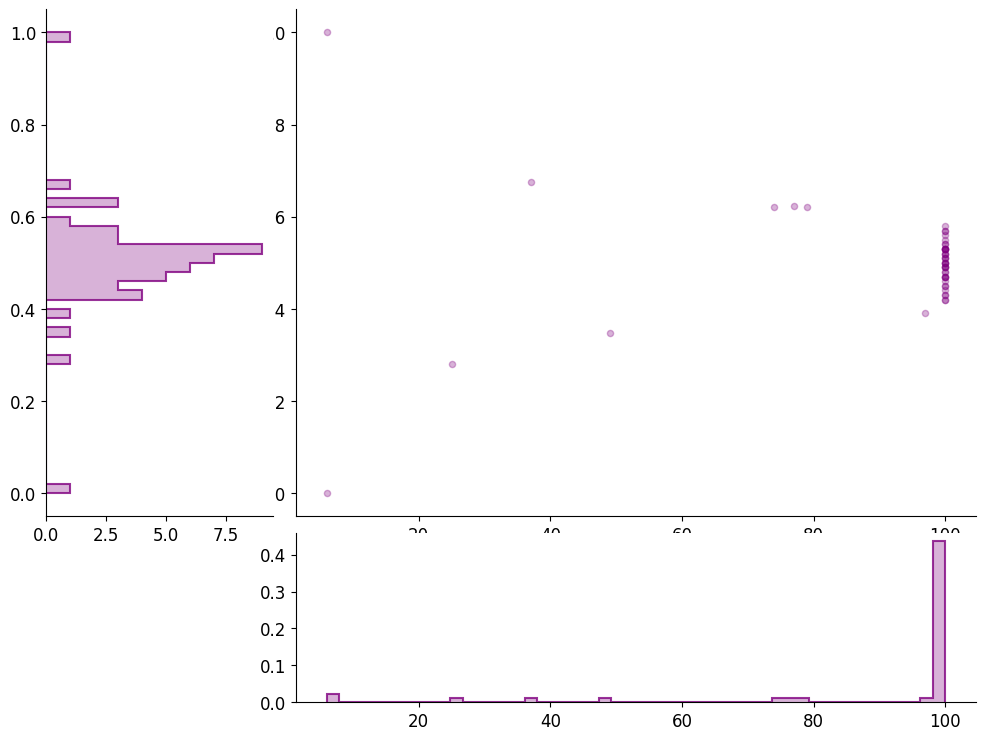

In [34]:
import matplotlib.gridspec as gridspec

scatter_ratio = 3

fig = plt.figure(figsize=(FIG_WIDTH * 1.5, FIG_HEIGHT * 1.5))

gs = gridspec.GridSpec(2, 2, width_ratios=[1, scatter_ratio], height_ratios=[scatter_ratio, 1], 
                        wspace=0.05, hspace=0.05)

ax_scatter = fig.add_subplot(gs[0, 1])
ax_left = fig.add_subplot(gs[0, 0], sharey=ax_scatter)
ax_bottom = fig.add_subplot(gs[1, 1], sharex=ax_scatter)


color = "purple"
ax_scatter.scatter(df_experiment_stats["trials"], df_experiment_stats["sample_success_rate"], 
                           alpha=0.3, color=color, label=None, marker=None, s=20)


# --- Bottom Panel: Iteration Histogram ---
# Calculate histogram first to capture densities
bins = 50
iter_counts, iter_bins = np.histogram(df_experiment_stats["trials"], bins=bins, density=True)
#iteration_max_densities.append(np.max(iter_counts))

ax_bottom.hist(df_experiment_stats["trials"], bins=bins, color=color, alpha=0.3, 
                density=True, histtype='stepfilled')
ax_bottom.hist(df_experiment_stats["trials"], bins=bins, color=color, alpha=0.8, 
                density=True, histtype='step', linewidth=1.5)


# --- Left Panel: Success Rate Histogram ---
success_counts, success_bins = np.histogram(df_experiment_stats["sample_success_rate"], bins=bins, density=True)


ax_left.hist(df_experiment_stats["sample_success_rate"], bins=bins, color=color, alpha=0.3, 
                density=True, histtype='stepfilled', orientation='horizontal')
ax_left.hist(df_experiment_stats["sample_success_rate"], bins=bins, color=color, alpha=0.8, 
                density=True, histtype='step', orientation='horizontal', linewidth=1.5)
pass

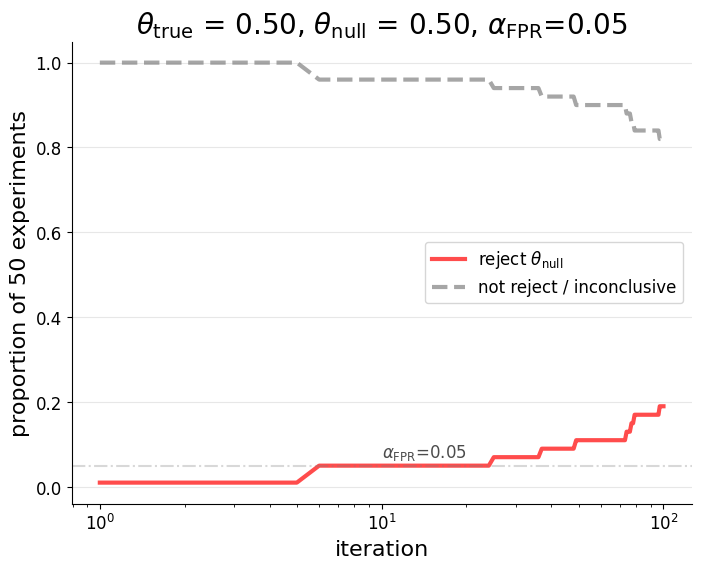

In [36]:
plot_decision_rates_nhst(N_EXPERIMENTS, hypo_0pt5_results['iteration_stopping_on_or_prior'],
 fpr=αfpr, success_rate_true=θ_true, success_rate_null=θ_null)